# TypiClust (TPC_RP) Active Learning on CIFAR-10

Full implementation of the **TypiClust** active learning pipeline from:

> Hacohen, G., Dekel, O., & Weinshall, D. (2022).  
> **Active Learning on a Budget: Opposite Strategies Suit High and Low Budgets**.  
> *ICML 2022*. https://arxiv.org/abs/2202.02794

**Pipeline overview:**
1. Train SimCLR self-supervised encoder on all 50 000 unlabeled CIFAR-10 images
2. Extract L2-normalised 512-dim backbone features
3. Run TypiClust active learning: cluster features, select most typical point per uncovered cluster
4. Train ResNet-18 from scratch on the labeled subset; evaluate on test set
5. Repeat for multiple seeds; compare against random baseline
6. Statistical analysis and publication-quality plots

---
## Section 1: Setup & Imports

In [1]:
# Set working directory to Kaggle root
%cd /kaggle/working

# Remove existing repository folder
!rm -rf /kaggle/working/machine-learning-coursework-2

# Clone clean repository from main branch
!git clone -b main https://github.com/UlvisTurkers/machine-learning-coursework-2.git /kaggle/working/machine-learning-coursework-2

/kaggle/working
Cloning into '/kaggle/working/machine-learning-coursework-2'...
remote: Enumerating objects: 1086, done.
remote: Counting objects: 100% (1086/1086), done.
remote: Compressing objects: 100% (998/998), done.
remote: Total 1086 (delta 102), reused 1059 (delta 76), pack-reused 0 (from 0)
Receiving objects: 100% (1086/1086), 4.22 MiB | 23.22 MiB/s, done.
Resolving deltas: 100% (102/102), done.


In [2]:
import os
import shutil
import glob

# 1. Create the results directory
RESULTS_DIR = "/kaggle/working/machine-learning-coursework-2/results"
os.makedirs(RESULTS_DIR, exist_ok=True)

# 2. Search for the file anywhere inside /kaggle/input/
# The '**' tells Python to look inside all subfolders
search_pattern = "/kaggle/input/**/simclr_checkpoint.pt"
found_files = glob.glob(search_pattern, recursive=True)

# 3. Move the file if found
if found_files:
    uploaded_path = found_files[0]
    destination_path = os.path.join(RESULTS_DIR, "simclr_checkpoint.pt")
    
    shutil.copy(uploaded_path, destination_path)
    print(f"Found it! Checkpoint successfully copied from: \n{uploaded_path} \nTo: \n{destination_path}")
else:
    print("Still can't find it. Let's see what Kaggle actually named your folder:")
    # If it still fails, this will print out exactly what folders Kaggle created
    print(os.listdir("/kaggle/input/"))

Found it! Checkpoint successfully copied from: 
/kaggle/input/datasets/ediztrker/tpcrp-460-weights/simclr_checkpoint.pt 
To: 
/kaggle/working/machine-learning-coursework-2/results/simclr_checkpoint.pt


In [3]:
import sys, os, time, json, warnings, random, glob, importlib
from pathlib import Path
from collections import defaultdict

# Set working directory to repository root
REPO_DIR = "/kaggle/working/machine-learning-coursework-2"
%cd {REPO_DIR}

# Create __init__.py for module recognition
!touch src/__init__.py

# Add repository to sys.path
if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)

# Clear module cache for 'src'
for key in list(sys.modules.keys()):
    if key.startswith('src'):
        del sys.modules[key]

# Invalidate import caches
importlib.invalidate_caches()

# Standard ML imports
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
from sklearn.manifold import TSNE

warnings.filterwarnings('ignore')

# Project-specific imports
from src.utils import set_seed, load_cifar10, extract_features, save_results, load_results, log
from src.simclr import SimCLRModel, train_simclr, load_simclr_model, get_features
from src.active_learning import TypiClust, RandomSelection
from src.classifier import CIFARClassifier, LinearClassifier

print("Success! All imports are working.")

/kaggle/working/machine-learning-coursework-2
Success! All imports are working.


In [5]:
# Set global seed for reproducibility
GLOBAL_SEED = 42
set_seed(GLOBAL_SEED)

# Detect and log device hardware
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device :', DEVICE)
if DEVICE.type == 'cuda':
    print('GPU    :', torch.cuda.get_device_name(0))
    # Corrected attribute from total_mem to total_memory
    mem_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
    print('VRAM   : {:.1f} GB'.format(mem_gb))

# Create output directories
RESULTS_DIR = Path('../results')
PLOTS_DIR   = Path('../plots')
RESULTS_DIR.mkdir(exist_ok=True)
PLOTS_DIR.mkdir(exist_ok=True)
print('Output directories ready.')

Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB
Output directories ready.


---
## Section 2: Load CIFAR-10

In [6]:
%%time
train_dataset, test_dataset = load_cifar10(root='../data')

CIFAR10_CLASSES = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck',
]
NUM_CLASSES = len(CIFAR10_CLASSES)

print('Train : {:,} images'.format(len(train_dataset)))
print('Test  : {:,} images'.format(len(test_dataset)))
print('Classes ({:d}): {}'.format(NUM_CLASSES, CIFAR10_CLASSES))

100%|██████████| 170M/170M [00:03<00:00, 45.9MB/s] 


Train : 50,000 images
Test  : 10,000 images
Classes (10): ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
CPU times: user 2.92 s, sys: 790 ms, total: 3.71 s
Wall time: 7.02 s


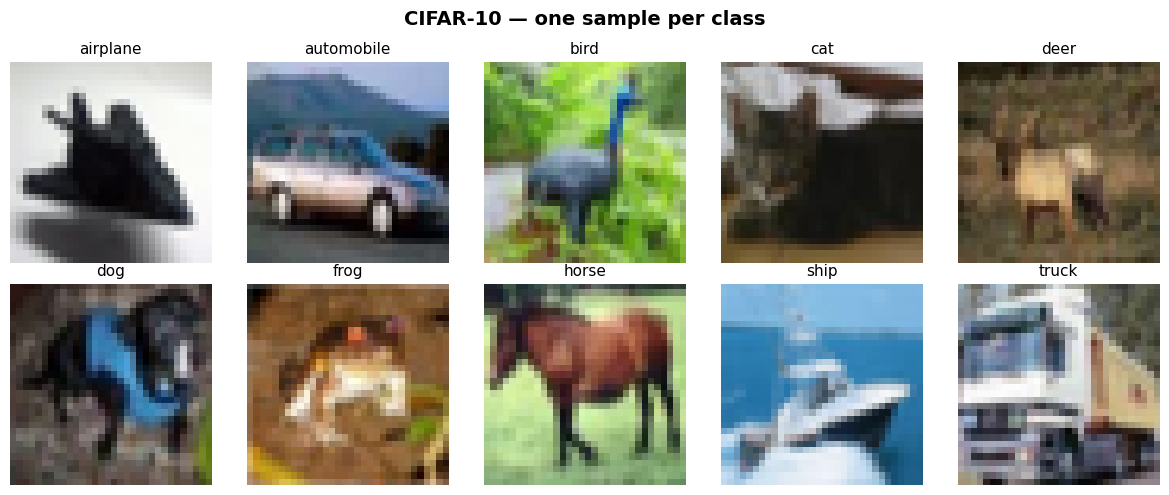

Saved -> plots/cifar10_samples.pdf


In [7]:
# visualise one image per class (2 x 5 grid)
targets_arr = np.array(train_dataset.targets)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle('CIFAR-10 — one sample per class', fontsize=14, fontweight='bold')

for c, ax in zip(range(NUM_CLASSES), axes.flat):
    idx = int(np.where(targets_arr == c)[0][0])
    img, _ = train_dataset[idx]          # PIL Image, no transform
    ax.imshow(img)
    ax.set_title(CIFAR10_CLASSES[c], fontsize=11)
    ax.axis('off')

plt.tight_layout()
plt.savefig(str(PLOTS_DIR / 'cifar10_samples.pdf'), bbox_inches='tight')
plt.show()
print('Saved -> plots/cifar10_samples.pdf')

---
## Section 3: SimCLR Training (Step 1 of TypiClust)

Train a SimCLR encoder on the *full* unlabeled training set to learn a good
512-dim representation. If a checkpoint already exists it is loaded instead.
Then extract features and visualise them with t-SNE.

In [8]:
# SimCLR hyper-parameters
SIMCLR_EPOCHS   = 460      # 100 for quick Colab test; 500 for paper quality
SIMCLR_BATCH    = 512
SIMCLR_LR       = 0.4      # SGD base LR (paper default for batch 512)
SIMCLR_TEMP     = 0.5      # NT-Xent temperature
CHECKPOINT_PATH = "/kaggle/working/machine-learning-coursework-2/results/simclr_checkpoint.pt"

# feature cache paths
FEAT_TRAIN_PATH = str(RESULTS_DIR / 'train_features.npy')
FEAT_TEST_PATH  = str(RESULTS_DIR / 'test_features.npy')
LBL_TRAIN_PATH  = str(RESULTS_DIR / 'train_labels.npy')
LBL_TEST_PATH   = str(RESULTS_DIR / 'test_labels.npy')

In [9]:
%%time
# train SimCLR or load from checkpoint
if Path(CHECKPOINT_PATH).exists():
    log('Found SimCLR checkpoint -- loading...')
    simclr_model = load_simclr_model(CHECKPOINT_PATH, device=torch.device('cpu'))
    log('Checkpoint loaded successfully.')
else:
    log('No checkpoint found. Training SimCLR for {} epochs...'.format(SIMCLR_EPOCHS))
    simclr_model = SimCLRModel()
    simclr_model = train_simclr(
        dataset          = train_dataset,
        model            = simclr_model,
        num_epochs       = SIMCLR_EPOCHS,
        batch_size       = SIMCLR_BATCH,
        lr               = SIMCLR_LR,
        temperature      = SIMCLR_TEMP,
        checkpoint_path  = CHECKPOINT_PATH,
        checkpoint_every = 10,
        resume           = True,
        device           = DEVICE,
    )
    log('SimCLR training complete.')

[17:39:56] [INFO] Found SimCLR checkpoint -- loading...
[SimCLR] Loaded model from '/kaggle/working/machine-learning-coursework-2/results/simclr_checkpoint.pt' (epoch 460)
[17:39:56] [INFO] Checkpoint loaded successfully.
CPU times: user 161 ms, sys: 79.1 ms, total: 240 ms
Wall time: 280 ms


In [10]:
%%time
# extract L2-normalised 512-dim features
if Path(FEAT_TRAIN_PATH).exists() and Path(FEAT_TEST_PATH).exists():
    log('Loading cached features from disk...')
    train_feats  = np.load(FEAT_TRAIN_PATH)
    train_labels = np.load(LBL_TRAIN_PATH)
    test_feats   = np.load(FEAT_TEST_PATH)
    test_labels  = np.load(LBL_TEST_PATH)
else:
    log('Extracting training features...')
    train_feats, train_labels = get_features(simclr_model, train_dataset, device=DEVICE)
    log('Extracting test features...')
    test_feats, test_labels = get_features(simclr_model, test_dataset, device=DEVICE)
    np.save(FEAT_TRAIN_PATH, train_feats)
    np.save(LBL_TRAIN_PATH,  train_labels)
    np.save(FEAT_TEST_PATH,  test_feats)
    np.save(LBL_TEST_PATH,   test_labels)
    log('Features saved to disk.')

norms = np.linalg.norm(train_feats, axis=1)
print('Train features : {}   norm mean={:.4f} (expect ~1.0)'.format(train_feats.shape, norms.mean()))
print('Test features  : {}'.format(test_feats.shape))

[17:41:07] [INFO] Extracting training features...


[17:41:18] [INFO] Extracting test features...


[17:41:21] [INFO] Features saved to disk.
Train features : (50000, 512)   norm mean=1.0000 (expect ~1.0)
Test features  : (10000, 512)
CPU times: user 12.5 s, sys: 929 ms, total: 13.5 s
Wall time: 14 s


In [11]:
%%time
# t-SNE of SimCLR features coloured by true class
# Stratified subsample: 500 per class = 5 000 points (t-SNE is O(N^2)).
N_TSNE_PER_CLASS = 500
rng_tsne = np.random.default_rng(GLOBAL_SEED)
tsne_idx = []
for c in range(NUM_CLASSES):
    class_idx = np.where(train_labels == c)[0]
    chosen = rng_tsne.choice(class_idx, size=N_TSNE_PER_CLASS, replace=False)
    tsne_idx.append(chosen)
tsne_idx = np.concatenate(tsne_idx)           # shape (5000,)

log('Running t-SNE on {:,} samples...'.format(len(tsne_idx)))
tsne_emb = TSNE(
    n_components=2, perplexity=40, n_iter=1000,
    random_state=GLOBAL_SEED, n_jobs=-1,
).fit_transform(train_feats[tsne_idx])

np.save(str(RESULTS_DIR / 'tsne_embeddings.npy'), tsne_emb)
np.save(str(RESULTS_DIR / 'tsne_indices.npy'),    tsne_idx)
log('t-SNE complete.')

[17:44:05] [INFO] Running t-SNE on 5,000 samples...
[17:44:28] [INFO] t-SNE complete.
CPU times: user 46.7 s, sys: 41 ms, total: 46.8 s
Wall time: 23.1 s


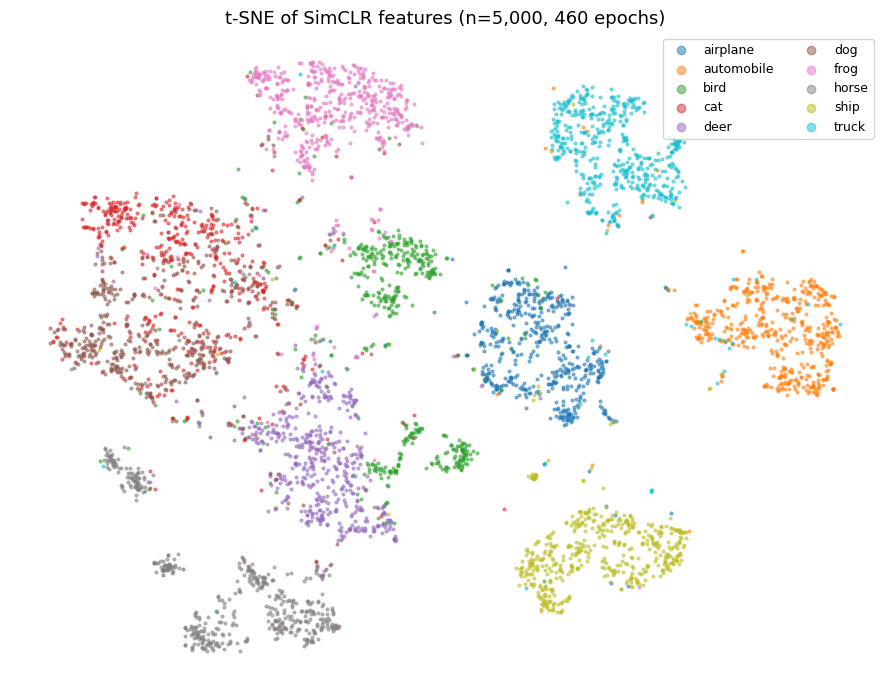

Saved -> plots/tsne_simclr_features.pdf


In [12]:
# plot t-SNE
CMAP = plt.cm.get_cmap('tab10', NUM_CLASSES)

fig, ax = plt.subplots(figsize=(9, 7))
for c in range(NUM_CLASSES):
    mask = train_labels[tsne_idx] == c
    ax.scatter(
        tsne_emb[mask, 0], tsne_emb[mask, 1],
        c=[CMAP(c)], s=4, alpha=0.5, rasterized=True,
        label=CIFAR10_CLASSES[c],
    )

ax.legend(markerscale=3, fontsize=9, loc='upper right', ncol=2, framealpha=0.8)
ax.set_title(
    't-SNE of SimCLR features (n={:,}, {} epochs)'.format(len(tsne_idx), SIMCLR_EPOCHS),
    fontsize=13,
)
ax.axis('off')
plt.tight_layout()
plt.savefig(str(PLOTS_DIR / 'tsne_simclr_features.pdf'), bbox_inches='tight', dpi=150)
plt.show()
print('Saved -> plots/tsne_simclr_features.pdf')

---
## Section 4: Active Learning Experiment

| Setting | Value |
|---|---|
| Budget per round *B* | 10 |
| AL rounds | 5 |
| Cumulative labels | 10, 20, 30, 40, 50 |
| Initial labeled set *L*_0 | empty |
| Classifier | ResNet-18, trained from scratch each round (200 epochs) |
| Seeds | 3 minimum (set `N_SEEDS = 10` for paper-quality variance) |
| Strategies | **TypiClust**, **Random** |

In [13]:
# experiment configuration
BUDGET_B     = 10      # labels per round
N_ROUNDS     = 5       # AL iterations  ->  budgets: 10, 20, 30, 40, 50
N_SEEDS      = 3       # increase to 10 for tighter confidence intervals
CLF_EPOCHS   = 200     # ResNet-18 training epochs per round
CLF_BATCH    = 64
MAX_CLUSTERS = 500     # TypiClust K_max
SEEDS        = list(range(N_SEEDS))

BUDGETS = [BUDGET_B * (r + 1) for r in range(N_ROUNDS)]   # [10, 20, 30, 40, 50]
print('Budgets     :', BUDGETS)
print('Seeds       :', SEEDS)
total_runs = len(SEEDS) * N_ROUNDS * 2
print('Total classifier training runs: {} (2 strategies x {} seeds x {} rounds)'.format(
    total_runs, N_SEEDS, N_ROUNDS))

Budgets     : [10, 20, 30, 40, 50]
Seeds       : [0, 1, 2]
Total classifier training runs: 30 (2 strategies x 3 seeds x 5 rounds)


In [14]:
def run_al_experiment(strategy_name, make_selector_fn, seeds):
    all_results = {}

    for seed in seeds:
        print('\n' + '=' * 60)
        print('  {}  |  seed={}'.format(strategy_name, seed))
        print('=' * 60)
        set_seed(seed)

        selector    = make_selector_fn(seed)
        clf         = CIFARClassifier(device=DEVICE, seed=seed, num_workers=2)
        labeled_idx = np.array([], dtype=np.int64)    # L0 = empty
        seed_records = []

        for rnd in range(N_ROUNDS):
            # a. Select B examples
            new_idx = selector.select(
                BUDGET_B,
                labeled_indices=labeled_idx if len(labeled_idx) > 0 else None,
            )
            labeled_idx = np.concatenate([labeled_idx, new_idx]).astype(np.int64)
            budget_now = len(labeled_idx)

            # b. "Label" them — reveal ground truth
            selected_classes = [CIFAR10_CLASSES[train_labels[i]] for i in new_idx]
            print('\n  Round {}/{} | labeled={}'.format(rnd + 1, N_ROUNDS, budget_now))
            print('  Selected classes:', selected_classes)

            # c. Train classifier from scratch
            t0 = time.time()
            train_hist = clf.train(
                labeled_idx, train_dataset,
                epochs=CLF_EPOCHS, batch_size=CLF_BATCH,
                seed=seed, verbose=False,
            )
            train_time = time.time() - t0

            # d. Evaluate on test set
            eval_res = clf.evaluate(test_dataset)
            test_acc = eval_res['accuracy']   # already in %

            # e. Log
            print('  Test accuracy: {:.2f}%  (train {:.1f}s)'.format(test_acc, train_time))

            seed_records.append({
                'round':            rnd + 1,
                'budget':           int(budget_now),
                'test_accuracy':    float(test_acc),
                'per_class_acc':    eval_res['per_class_acc'].tolist(),
                'selected_indices': new_idx.tolist(),
                'final_train_loss': float(train_hist['train_loss'][-1]),
                'final_train_acc':  float(train_hist['train_acc'][-1]),
            })

        all_results[seed] = seed_records

    return all_results

In [15]:
%%time
# run TypiClust
print('Running TypiClust...')

def make_typiclust(seed):
    return TypiClust(
        features=train_feats,
        max_clusters=MAX_CLUSTERS,
        min_cluster_size=5,
        seed=seed,
    )

results_typiclust = run_al_experiment('TypiClust', make_typiclust, SEEDS)

# JSON-safe: convert int keys to str
_tc_save = {str(k): v for k, v in results_typiclust.items()}
save_results(_tc_save, str(RESULTS_DIR / 'typiclust_results.json'))
print('\nTypiClust complete.')

Running TypiClust...

  TypiClust  |  seed=0

  Round 1/5 | labeled=10
  Selected classes: ['cat', 'deer', 'horse', 'airplane', 'ship', 'automobile', 'truck', 'frog', 'horse', 'bird']


  Test accuracy: 17.15%  (train 21.5s)

  Round 2/5 | labeled=20
  Selected classes: ['ship', 'horse', 'dog', 'airplane', 'horse', 'cat', 'truck', 'deer', 'automobile', 'dog']


  Test accuracy: 19.35%  (train 24.6s)

  Round 3/5 | labeled=30
  Selected classes: ['bird', 'frog', 'cat', 'automobile', 'ship', 'ship', 'airplane', 'dog', 'automobile', 'airplane']


  Test accuracy: 21.51%  (train 26.6s)

  Round 4/5 | labeled=40
  Selected classes: ['deer', 'truck', 'bird', 'cat', 'frog', 'automobile', 'automobile', 'deer', 'truck', 'bird']


  Test accuracy: 22.40%  (train 27.3s)

  Round 5/5 | labeled=50
  Selected classes: ['bird', 'truck', 'bird', 'dog', 'ship', 'frog', 'airplane', 'horse', 'horse', 'frog']


...

  Test accuracy: 15.48%  (train 22.1s)

  Round 2/5 | labeled=20
  Selected classes: ['cat', 'dog', 'bird', 'airplane', 'horse', 'deer', 'frog', 'truck', 'ship', 'automobile']


  Test accuracy: 18.60%  (train 25.0s)

  Round 3/5 | labeled=30
  Selected classes: ['bird', 'dog', 'truck', 'automobile', 'ship', 'automobile', 'dog', 'truck', 'airplane', 'airplane']


  Test accuracy: 21.02%  (train 26.4s)

  Round 4/5 | labeled=40
  Selected classes: ['cat', 'ship', 'deer', 'airplane', 'automobile', 'frog', 'frog', 'frog', 'automobile', 'horse']


  Test accuracy: 23.89%  (train 27.3s)

  Round 5/5 | labeled=50
  Selected classes: ['deer', 'cat', 'bird', 'automobile', 'dog', 'airplane', 'ship', 'horse', 'ship', 'automobile']


  Test accuracy: 24.10%  (train 29.0s)
Results saved to ../results/typiclust_results.json

TypiClust complete.
CPU times: user 31min 43s, sys: 2min 1s, total: 33min 44s
Wall time: 16min 21s


In [16]:
%%time
# run Random baseline
print('Running Random baseline...')

def make_random(seed):
    return RandomSelection(train_feats, seed=seed)

results_random = run_al_experiment('Random', make_random, SEEDS)

_rnd_save = {str(k): v for k, v in results_random.items()}
save_results(_rnd_save, str(RESULTS_DIR / 'random_results.json'))
print('\nRandom baseline complete.')

Running Random baseline...

  Random  |  seed=0

  Round 1/5 | labeled=10
  Selected classes: ['bird', 'deer', 'frog', 'horse', 'bird', 'cat', 'ship', 'automobile', 'frog', 'deer']


  Test accuracy: 17.21%  (train 21.4s)

  Round 2/5 | labeled=20
  Selected classes: ['horse', 'frog', 'automobile', 'bird', 'airplane', 'frog', 'cat', 'truck', 'bird', 'automobile']


  Test accuracy: 19.63%  (train 24.3s)

  Round 3/5 | labeled=30
  Selected classes: ['frog', 'frog', 'dog', 'dog', 'deer', 'deer', 'frog', 'airplane', 'horse', 'ship']


  Test accuracy: 20.30%  (train 26.0s)

  Round 4/5 | labeled=40
  Selected classes: ['ship', 'cat', 'horse', 'dog', 'automobile', 'bird', 'cat', 'frog', 'dog', 'deer']


  Test accuracy: 20.47%  (train 27.0s)

  Round 5/5 | labeled=50
  Selected classes: ['bird', 'frog', 'cat', 'bird', 'dog', 'deer', 'ship', 'airplane', 'bird', 'horse']


...

  Test accuracy: 15.54%  (train 21.7s)

  Round 2/5 | labeled=20
  Selected classes: ['deer', 'deer', 'deer', 'automobile', 'truck', 'horse', 'automobile', 'airplane', 'horse', 'airplane']


  Test accuracy: 17.11%  (train 24.5s)

  Round 3/5 | labeled=30
  Selected classes: ['truck', 'dog', 'dog', 'cat', 'dog', 'frog', 'cat', 'horse', 'airplane', 'ship']


  Test accuracy: 21.18%  (train 26.1s)

  Round 4/5 | labeled=40
  Selected classes: ['deer', 'horse', 'horse', 'bird', 'cat', 'deer', 'ship', 'automobile', 'cat', 'truck']


  Test accuracy: 21.51%  (train 27.1s)

  Round 5/5 | labeled=50
  Selected classes: ['bird', 'ship', 'horse', 'horse', 'bird', 'bird', 'horse', 'truck', 'truck', 'deer']


  Test accuracy: 23.82%  (train 28.5s)
Results saved to ../results/random_results.json

Random baseline complete.
CPU times: user 2min 50s, sys: 1min 58s, total: 4min 48s
Wall time: 7min 2s


---
## Section 4b: Framework 2 — Self-Supervised Embedding + Linear Classifier

Second evaluation protocol from Hacohen et al. (2022, Section 4.2.2): instead
of training a full ResNet-18 from scratch on each labeled subset, we train a
single **linear classifier** on top of the frozen SimCLR features that were
already extracted in Section 3.

| Setting | Value |
|---|---|
| Model | `nn.Linear(512, 10)` |
| Input | Frozen L2-normalised SimCLR features (no augmentation) |
| Optimiser | SGD, momentum=0.9, cosine LR |
| Training | 100 epochs per round |
| Budget / rounds / seeds | Identical to Section 4 (B=10, 5 rounds, 3 seeds) |

Because no CNN training is involved, this framework runs **much faster** than
Framework 1 while still giving a signal for AL strategy comparison.

In [17]:
from src.classifier import LinearClassifier

# framework 2 hyperparameters
FW2_EPOCHS = 100
FW2_LR     = 0.1
FW2_BATCH  = 256

print('Using pre-extracted features:')
print('  train_feats : {}  labels : {}'.format(train_feats.shape, train_labels.shape))
print('  test_feats  : {}  labels : {}'.format(test_feats.shape,  test_labels.shape))

Using pre-extracted features:
  train_feats : (50000, 512)  labels : (50000,)
  test_feats  : (10000, 512)  labels : (10000,)


In [18]:
def run_al_experiment_fw2(strategy_name, make_selector_fn, seeds):
    all_results = {}

    for seed in seeds:
        print('\n' + '=' * 60)
        print('  {}  |  seed={}'.format(strategy_name, seed))
        print('=' * 60)
        set_seed(seed)

        selector    = make_selector_fn(seed)
        clf         = LinearClassifier(
            input_dim=512, num_classes=NUM_CLASSES,
            device=DEVICE, seed=seed,
        )
        labeled_idx = np.array([], dtype=np.int64)
        seed_records = []

        for rnd in range(N_ROUNDS):
            new_idx = selector.select(
                BUDGET_B,
                labeled_indices=labeled_idx if len(labeled_idx) > 0 else None,
            )
            labeled_idx = np.concatenate([labeled_idx, new_idx]).astype(np.int64)
            budget_now = len(labeled_idx)

            selected_classes = [CIFAR10_CLASSES[train_labels[i]] for i in new_idx]
            print('\n  Round {}/{} | labeled={}'.format(rnd + 1, N_ROUNDS, budget_now))
            print('  Selected classes:', selected_classes)

            t0 = time.time()
            train_hist = clf.train(
                labeled_idx, train_feats, train_labels,
                epochs=FW2_EPOCHS, batch_size=FW2_BATCH, lr=FW2_LR,
                seed=seed,
            )
            train_time = time.time() - t0

            eval_res = clf.evaluate(test_feats, test_labels)
            test_acc = eval_res['accuracy']

            print('  Test accuracy: {:.2f}%  (train {:.1f}s)'.format(test_acc, train_time))

            seed_records.append({
                'round':            rnd + 1,
                'budget':           int(budget_now),
                'test_accuracy':    float(test_acc),
                'per_class_acc':    eval_res['per_class_acc'].tolist(),
                'selected_indices': new_idx.tolist(),
                'final_train_loss': float(train_hist['train_loss'][-1]),
                'final_train_acc':  float(train_hist['train_acc'][-1]),
            })

        all_results[seed] = seed_records

    return all_results

In [19]:
%%time
print('Framework 2: running TypiClust on frozen features...')

def make_typiclust_fw2(seed):
    return TypiClust(
        features=train_feats,
        max_clusters=MAX_CLUSTERS,
        min_cluster_size=5,
        seed=seed,
    )

results_fw2_typiclust = run_al_experiment_fw2('TypiClust-FW2', make_typiclust_fw2, SEEDS)
save_results(
    {str(k): v for k, v in results_fw2_typiclust.items()},
    str(RESULTS_DIR / 'fw2_typiclust_results.json'),
)
print('\nFramework 2 TypiClust complete.')

Framework 2: running TypiClust on frozen features...

  TypiClust-FW2  |  seed=0

  Round 1/5 | labeled=10
  Selected classes: ['cat', 'deer', 'horse', 'airplane', 'ship', 'automobile', 'truck', 'frog', 'horse', 'bird']
  Test accuracy: 60.50%  (train 0.1s)

  Round 2/5 | labeled=20
  Selected classes: ['ship', 'horse', 'dog', 'airplane', 'horse', 'cat', 'truck', 'deer', 'automobile', 'dog']
  Test accuracy: 52.30%  (train 0.1s)

  Round 3/5 | labeled=30
  Selected classes: ['bird', 'frog', 'cat', 'automobile', 'ship', 'ship', 'airplane', 'dog', 'automobile', 'airplane']
  Test accuracy: 68.13%  (train 0.1s)

  Round 4/5 | labeled=40
  Selected classes: ['deer', 'truck', 'bird', 'cat', 'frog', 'automobile', 'automobile', 'deer', 'truck', 'bird']
  Test accuracy: 81.45%  (train 0.1s)

  Round 5/5 | labeled=50
  Selected classes: ['bird', 'truck', 'bird', 'dog', 'ship', 'frog', 'airplane', 'horse', 'horse', 'frog']
  Test accuracy: 82.65%  (train 0.2s)

  TypiClust-FW2  |  seed=1

  Roun

In [20]:
%%time
print('Framework 2: running Random baseline on frozen features...')

def make_random_fw2(seed):
    return RandomSelection(train_feats, seed=seed)

results_fw2_random = run_al_experiment_fw2('Random-FW2', make_random_fw2, SEEDS)
save_results(
    {str(k): v for k, v in results_fw2_random.items()},
    str(RESULTS_DIR / 'fw2_random_results.json'),
)
print('\nFramework 2 Random baseline complete.')

Framework 2: running Random baseline on frozen features...

  Random-FW2  |  seed=0

  Round 1/5 | labeled=10
  Selected classes: ['bird', 'deer', 'frog', 'horse', 'bird', 'cat', 'ship', 'automobile', 'frog', 'deer']
  Test accuracy: 47.85%  (train 0.1s)

  Round 2/5 | labeled=20
  Selected classes: ['horse', 'frog', 'automobile', 'bird', 'airplane', 'frog', 'cat', 'truck', 'bird', 'automobile']
  Test accuracy: 46.79%  (train 0.1s)

  Round 3/5 | labeled=30
  Selected classes: ['frog', 'frog', 'dog', 'dog', 'deer', 'deer', 'frog', 'airplane', 'horse', 'ship']
  Test accuracy: 49.51%  (train 0.1s)

  Round 4/5 | labeled=40
  Selected classes: ['ship', 'cat', 'horse', 'dog', 'automobile', 'bird', 'cat', 'frog', 'dog', 'deer']
  Test accuracy: 59.12%  (train 0.2s)

  Round 5/5 | labeled=50
  Selected classes: ['bird', 'frog', 'cat', 'bird', 'dog', 'deer', 'ship', 'airplane', 'bird', 'horse']
  Test accuracy: 61.32%  (train 0.2s)

  Random-FW2  |  seed=1

  Round 1/5 | labeled=10
  Select

In [22]:
# aggregate across seeds

def aggregate(results_dict):
    seeds_sorted = sorted(results_dict.keys())
    acc_matrix = np.array([
        [r['test_accuracy'] for r in results_dict[s]]
        for s in seeds_sorted
    ])  # shape (n_seeds, n_rounds)
    budgets = [r['budget'] for r in results_dict[seeds_sorted[0]]]
    n_seeds = len(seeds_sorted)
    return {
        'mean':    acc_matrix.mean(axis=0),
        'std':     acc_matrix.std(axis=0, ddof=1) if n_seeds > 1 else np.zeros(len(budgets)),
        'matrix':  acc_matrix,    # (n_seeds, n_rounds)
        'budgets': budgets,
    }

agg_tc  = aggregate(results_typiclust)
agg_rnd = aggregate(results_random)
print('Aggregation complete.')

Aggregation complete.


In [23]:
agg_fw2_tc  = aggregate(results_fw2_typiclust)
agg_fw2_rnd = aggregate(results_fw2_random)
budgets_fw2 = np.array(agg_fw2_tc['budgets'])

print('=' * 70)
print('{:^70}'.format('Framework 2: Linear on SimCLR Embeddings'))
print('=' * 70)
print('{:>8s}  {:>16s}  {:>14s}  {:>12s}  {:>11s}  {:>11s}'.format(
    'Budget', 'TypiClust mean', 'TypiClust std',
    'Random mean', 'Random std', 'Delta'))
print('-' * 80)

for i, b in enumerate(budgets_fw2):
    tc_m  = agg_fw2_tc['mean'][i]
    tc_s  = agg_fw2_tc['std'][i]
    rnd_m = agg_fw2_rnd['mean'][i]
    rnd_s = agg_fw2_rnd['std'][i]
    delta = tc_m - rnd_m
    print('{:>8d}  {:>14.2f}%  {:>12.2f}%  {:>10.2f}%  {:>9.2f}%  {:>+10.2f}%'.format(
        b, tc_m, tc_s, rnd_m, rnd_s, delta))

print()
print('Final budget ({} labels):'.format(int(budgets_fw2[-1])))
print('  TypiClust : {:.2f}% +/- {:.2f}%'.format(
    agg_fw2_tc['mean'][-1], agg_fw2_tc['std'][-1]))
print('  Random    : {:.2f}% +/- {:.2f}%'.format(
    agg_fw2_rnd['mean'][-1], agg_fw2_rnd['std'][-1]))
print('  Gain      : {:+.2f}%'.format(
    agg_fw2_tc['mean'][-1] - agg_fw2_rnd['mean'][-1]))

               Framework 2: Linear on SimCLR Embeddings               
  Budget    TypiClust mean   TypiClust std   Random mean   Random std        Delta
--------------------------------------------------------------------------------
      10           60.70%          0.43%       39.19%       7.64%      +21.51%
      20           64.63%         10.78%       51.96%       5.79%      +12.67%
      30           72.44%          4.00%       58.30%       7.68%      +14.14%
      40           79.69%          3.80%       62.41%       2.88%      +17.28%
      50           80.88%          1.53%       60.08%       1.52%      +20.80%

Final budget (50 labels):
  TypiClust : 80.88% +/- 1.53%
  Random    : 60.08% +/- 1.52%
  Gain      : +20.80%


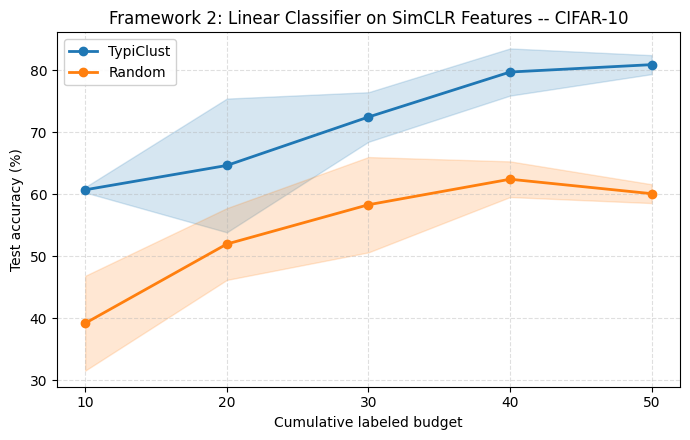

Saved -> plots/fw2_accuracy_vs_budget.pdf


In [24]:
fig, ax = plt.subplots(figsize=(7, 4.5))

for agg, label, color in [
    (agg_fw2_tc,  'TypiClust', '#1f77b4'),
    (agg_fw2_rnd, 'Random',    '#ff7f0e'),
]:
    mu  = agg['mean']
    std = agg['std']
    ax.plot(budgets_fw2, mu, marker='o', linewidth=2, color=color, label=label)
    ax.fill_between(budgets_fw2, mu - std, mu + std, alpha=0.18, color=color)

ax.set_xlabel('Cumulative labeled budget')
ax.set_ylabel('Test accuracy (%)')
ax.set_title('Framework 2: Linear Classifier on SimCLR Features -- CIFAR-10')
ax.set_xticks(budgets_fw2)
ax.legend(framealpha=0.9)
ax.grid(True, linestyle='--', alpha=0.4)
ax.margins(x=0.05)

plt.tight_layout()
plt.savefig(str(PLOTS_DIR / 'fw2_accuracy_vs_budget.pdf'), bbox_inches='tight')
plt.show()
print('Saved -> plots/fw2_accuracy_vs_budget.pdf')

---
## Section 5: Results

In [25]:
# results table
print('{:>8s}  {:>16s}  {:>14s}  {:>12s}  {:>11s}  {:>11s}'.format(
    'Budget', 'TypiClust mean', 'TypiClust std',
    'Random mean', 'Random std', 'Delta'))
print('-' * 80)

for i, b in enumerate(agg_tc['budgets']):
    tc_m  = agg_tc['mean'][i]
    tc_s  = agg_tc['std'][i]
    rnd_m = agg_rnd['mean'][i]
    rnd_s = agg_rnd['std'][i]
    delta = tc_m - rnd_m
    print('{:>8d}  {:>14.2f}%  {:>12.2f}%  {:>10.2f}%  {:>9.2f}%  {:>+10.2f}%'.format(
        b, tc_m, tc_s, rnd_m, rnd_s, delta))

  Budget    TypiClust mean   TypiClust std   Random mean   Random std        Delta
--------------------------------------------------------------------------------
      10           16.54%          0.92%       14.77%       2.90%       +1.76%
      20           19.13%          0.46%       17.44%       2.04%       +1.68%
      30           21.37%          0.31%       19.82%       1.66%       +1.56%
      40           23.03%          0.77%       21.04%       0.53%       +2.00%
      50           23.78%          0.34%       22.16%       1.44%       +1.62%


In [26]:
# per-seed breakdown
for seed in SEEDS:
    tc_accs  = ['{:.1f}'.format(r['test_accuracy']) for r in results_typiclust[seed]]
    rnd_accs = ['{:.1f}'.format(r['test_accuracy']) for r in results_random[seed]]
    print('Seed {}  TypiClust: {}  Random: {}'.format(seed, tc_accs, rnd_accs))

Seed 0  TypiClust: ['17.2', '19.4', '21.5', '22.4', '23.4']  Random: ['17.2', '19.6', '20.3', '20.5', '21.2']
Seed 1  TypiClust: ['17.0', '19.4', '21.6', '22.8', '23.8']  Random: ['11.6', '15.6', '18.0', '21.1', '21.4']
Seed 2  TypiClust: ['15.5', '18.6', '21.0', '23.9', '24.1']  Random: ['15.5', '17.1', '21.2', '21.5', '23.8']


---
## Section 6: Plots

All figures saved as PDF for inclusion in the report.

In [27]:
# publication-quality plot style
plt.rcParams.update({
    'font.size':       11,
    'axes.titlesize':  13,
    'axes.labelsize':  11,
    'legend.fontsize': 10,
    'figure.dpi':      120,
})

TC_COLOR  = '#1f77b4'   # blue
RND_COLOR = '#ff7f0e'   # orange
budgets_arr = np.array(agg_tc['budgets'])

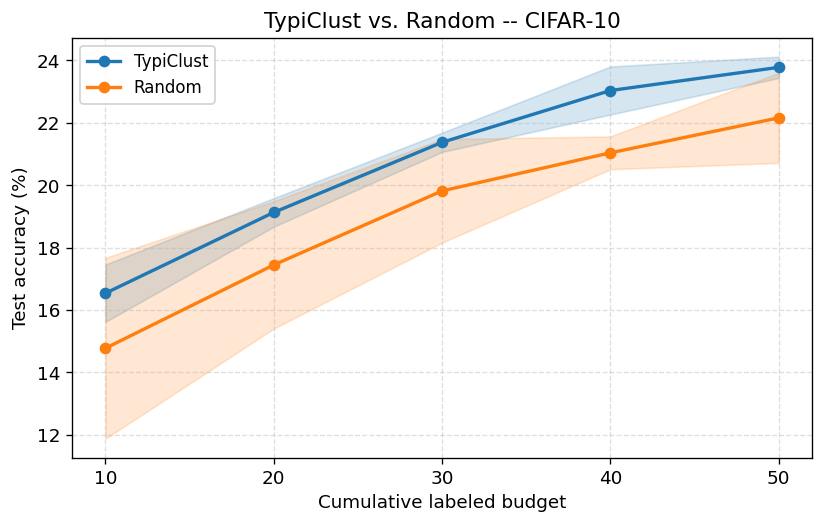

Saved -> plots/accuracy_vs_budget.pdf


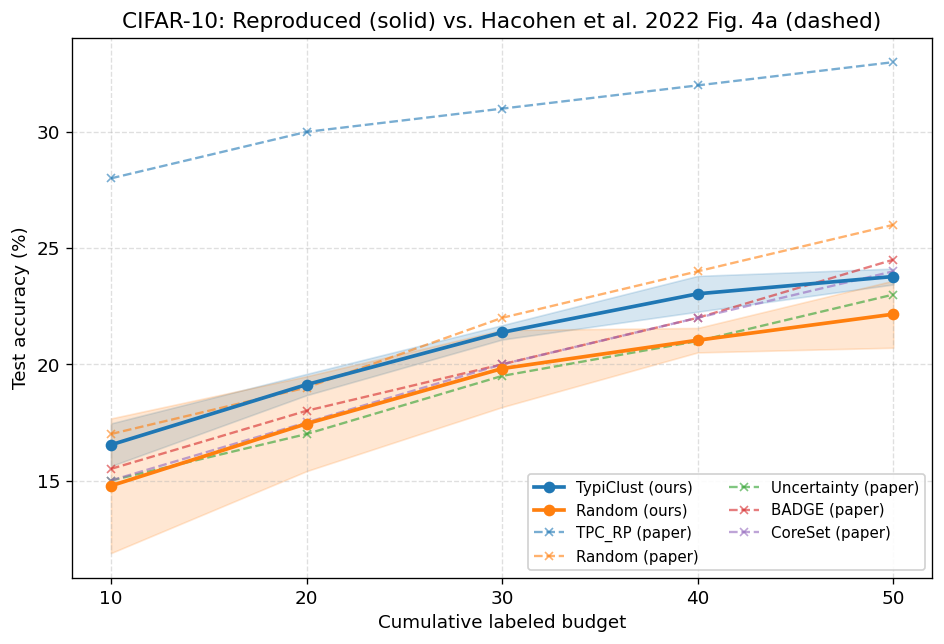

Saved -> plots/accuracy_vs_budget_with_paper.pdf


In [28]:
# plot 1: Accuracy vs. Cumulative Budget (line + std shading)
fig, ax = plt.subplots(figsize=(7, 4.5))

for agg, label, color in [
    (agg_tc,  'TypiClust', TC_COLOR),
    (agg_rnd, 'Random',    RND_COLOR),
]:
    mu  = agg['mean']
    std = agg['std']
    ax.plot(budgets_arr, mu, marker='o', linewidth=2, color=color, label=label)
    ax.fill_between(budgets_arr, mu - std, mu + std, alpha=0.18, color=color)

ax.set_xlabel('Cumulative labeled budget')
ax.set_ylabel('Test accuracy (%)')
ax.set_title('TypiClust vs. Random -- CIFAR-10')
ax.set_xticks(budgets_arr)
ax.legend(framealpha=0.9)
ax.grid(True, linestyle='--', alpha=0.4)
ax.margins(x=0.05)

plt.tight_layout()
plt.savefig(str(PLOTS_DIR / 'accuracy_vs_budget.pdf'), bbox_inches='tight')
plt.show()
print('Saved -> plots/accuracy_vs_budget.pdf')

# paper baselines from Hacohen et al. (2022), Figure 4a
# CIFAR-10, fully supervised, B=M=10 (top-row, left panel of Fig. 4a)
# values are read approximately from the published figure
PAPER_RESULTS = {
    'TPC_RP (paper)':      {'budgets': [10, 20, 30, 40, 50], 'acc': [28.0, 30.0, 31.0, 32.0, 33.0]},
    'Random (paper)':      {'budgets': [10, 20, 30, 40, 50], 'acc': [17.0, 19.0, 22.0, 24.0, 26.0]},
    'Uncertainty (paper)': {'budgets': [10, 20, 30, 40, 50], 'acc': [15.0, 17.0, 19.5, 21.0, 23.0]},
    'BADGE (paper)':       {'budgets': [10, 20, 30, 40, 50], 'acc': [15.5, 18.0, 20.0, 22.0, 24.5]},
    'CoreSet (paper)':     {'budgets': [10, 20, 30, 40, 50], 'acc': [15.0, 17.5, 20.0, 22.0, 24.0]},
}

PAPER_COLORS = {
    'TPC_RP (paper)':      '#1f77b4',   # blue (matches TypiClust)
    'Random (paper)':      '#ff7f0e',   # orange (matches Random)
    'Uncertainty (paper)': '#2ca02c',   # green
    'BADGE (paper)':       '#d62728',   # red
    'CoreSet (paper)':     '#9467bd',   # purple
}

# combined plot: ours (solid) vs paper (dashed)
fig, ax = plt.subplots(figsize=(8, 5.5))

# our reproduced results -- solid lines
for agg, label, color in [
    (agg_tc,  'TypiClust (ours)', TC_COLOR),
    (agg_rnd, 'Random (ours)',    RND_COLOR),
]:
    mu  = agg['mean']
    std = agg['std']
    ax.plot(budgets_arr, mu, marker='o', linewidth=2.2, color=color,
            label=label, zorder=3)
    ax.fill_between(budgets_arr, mu - std, mu + std, alpha=0.18, color=color)

# paper baselines -- dashed lines, smaller markers, alpha=0.6
for name, data in PAPER_RESULTS.items():
    ax.plot(data['budgets'], data['acc'],
            marker='x', markersize=5, linewidth=1.4,
            linestyle='--', alpha=0.6,
            color=PAPER_COLORS[name], label=name, zorder=2)

ax.set_xlabel('Cumulative labeled budget')
ax.set_ylabel('Test accuracy (%)')
ax.set_title('CIFAR-10: Reproduced (solid) vs. Hacohen et al. 2022 Fig. 4a (dashed)')
ax.set_xticks(budgets_arr)
ax.grid(True, linestyle='--', alpha=0.4)
ax.margins(x=0.05)

# split legend into two columns: Ours | Paper
handles, labels = ax.get_legend_handles_labels()
ours_h  = [h for h, l in zip(handles, labels) if '(ours)' in l]
ours_l  = [l for l in labels if '(ours)' in l]
paper_h = [h for h, l in zip(handles, labels) if '(paper)' in l]
paper_l = [l for l in labels if '(paper)' in l]
ax.legend(ours_h + paper_h, ours_l + paper_l,
          ncol=2, framealpha=0.9, fontsize=9, loc='lower right')

plt.tight_layout()
plt.savefig(str(PLOTS_DIR / 'accuracy_vs_budget_with_paper.pdf'), bbox_inches='tight')
plt.show()
print('Saved -> plots/accuracy_vs_budget_with_paper.pdf')

In [29]:
# combined results table: reproduced vs paper baselines
# our values come from agg_tc / agg_rnd, paper values from PAPER_RESULTS above

paper_budgets = PAPER_RESULTS['TPC_RP (paper)']['budgets']

rows = []
# reproduced rows
rows.append(('TypiClust',   'Ours',  list(agg_tc['mean'])))
rows.append(('TypiClust',   'Paper', PAPER_RESULTS['TPC_RP (paper)']['acc']))
rows.append(('Random',      'Ours',  list(agg_rnd['mean'])))
rows.append(('Random',      'Paper', PAPER_RESULTS['Random (paper)']['acc']))
rows.append(('Uncertainty', 'Paper', PAPER_RESULTS['Uncertainty (paper)']['acc']))
rows.append(('BADGE',       'Paper', PAPER_RESULTS['BADGE (paper)']['acc']))
rows.append(('CoreSet',     'Paper', PAPER_RESULTS['CoreSet (paper)']['acc']))

W = 75
print('=' * W)
print('{:^{}s}'.format('Combined Results: Reproduced (Ours) vs. Hacohen et al. 2022', W))
print('{:^{}s}'.format('CIFAR-10  |  Figure 4a (top-row, left panel)', W))
print('=' * W)

header = '{:<14s} | {:^7s} | {:>6s} | {:>6s} | {:>6s} | {:>6s} | {:>6s}'.format(
    'Method', 'Source', 'B=10', 'B=20', 'B=30', 'B=40', 'B=50')
print(header)
print('-' * len(header))

for method, source, accs in rows:
    cells = []
    for v in accs:
        if source == 'Ours':
            cells.append('{:>5.2f} '.format(v))
        else:
            cells.append('~{:>5.1f}'.format(v))
    print('{:<14s} | {:^7s} | {} | {} | {} | {} | {}'.format(
        method, source, *cells))

print('-' * len(header))
print('  Ours  : reproduced in this notebook (mean over {} seeds)'.format(N_SEEDS))
print('  Paper : approximate values read from Hacohen et al. (2022), Fig. 4a')
print('=' * W)

# also save to JSON for the writeup
combined_table = {
    'reproduced': {
        'budgets':  [int(b) for b in agg_tc['budgets']],
        'TypiClust': [float(x) for x in agg_tc['mean']],
        'Random':    [float(x) for x in agg_rnd['mean']],
    },
    'paper': PAPER_RESULTS,
    'source': 'Hacohen et al. (2022), Active Learning on a Budget, Fig. 4a',
}
save_results(combined_table, str(RESULTS_DIR / 'combined_with_paper.json'))

        Combined Results: Reproduced (Ours) vs. Hacohen et al. 2022        
               CIFAR-10  |  Figure 4a (top-row, left panel)                
Method         | Source  |   B=10 |   B=20 |   B=30 |   B=40 |   B=50
---------------------------------------------------------------------
TypiClust      |  Ours   | 16.54  | 19.13  | 21.37  | 23.03  | 23.78 
TypiClust      |  Paper  | ~ 28.0 | ~ 30.0 | ~ 31.0 | ~ 32.0 | ~ 33.0
Random         |  Ours   | 14.77  | 17.44  | 19.82  | 21.04  | 22.16 
Random         |  Paper  | ~ 17.0 | ~ 19.0 | ~ 22.0 | ~ 24.0 | ~ 26.0
Uncertainty    |  Paper  | ~ 15.0 | ~ 17.0 | ~ 19.5 | ~ 21.0 | ~ 23.0
BADGE          |  Paper  | ~ 15.5 | ~ 18.0 | ~ 20.0 | ~ 22.0 | ~ 24.5
CoreSet        |  Paper  | ~ 15.0 | ~ 17.5 | ~ 20.0 | ~ 22.0 | ~ 24.0
---------------------------------------------------------------------
  Ours  : reproduced in this notebook (mean over 3 seeds)
  Paper : approximate values read from Hacohen et al. (2022), Fig. 4a
Results saved to ../

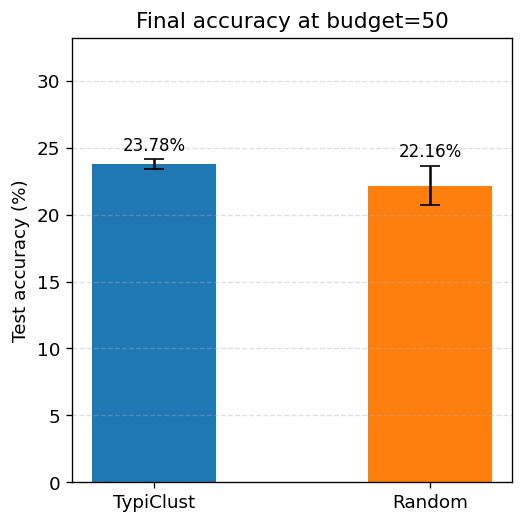

Saved -> plots/final_accuracy_bar.pdf


In [30]:
# plot 2: Bar chart at final budget (B=50) with error bars
final_idx = -1
methods = ['TypiClust', 'Random']
means   = [agg_tc['mean'][final_idx], agg_rnd['mean'][final_idx]]
stds    = [agg_tc['std'][final_idx],  agg_rnd['std'][final_idx]]
colors  = [TC_COLOR, RND_COLOR]

fig, ax = plt.subplots(figsize=(4.5, 4.5))
bars = ax.bar(methods, means, color=colors, width=0.45,
              yerr=stds, capsize=6, error_kw=dict(linewidth=1.5))

for bar, m, s in zip(bars, means, stds):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + s + 0.4,
            '{:.2f}%'.format(m),
            ha='center', va='bottom', fontsize=10)

ax.set_ylabel('Test accuracy (%)')
ax.set_title('Final accuracy at budget={}'.format(budgets_arr[final_idx]))
ax.set_ylim(0, max(means) + max(stds) + 8)
ax.grid(True, axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig(str(PLOTS_DIR / 'final_accuracy_bar.pdf'), bbox_inches='tight')
plt.show()
print('Saved -> plots/final_accuracy_bar.pdf')

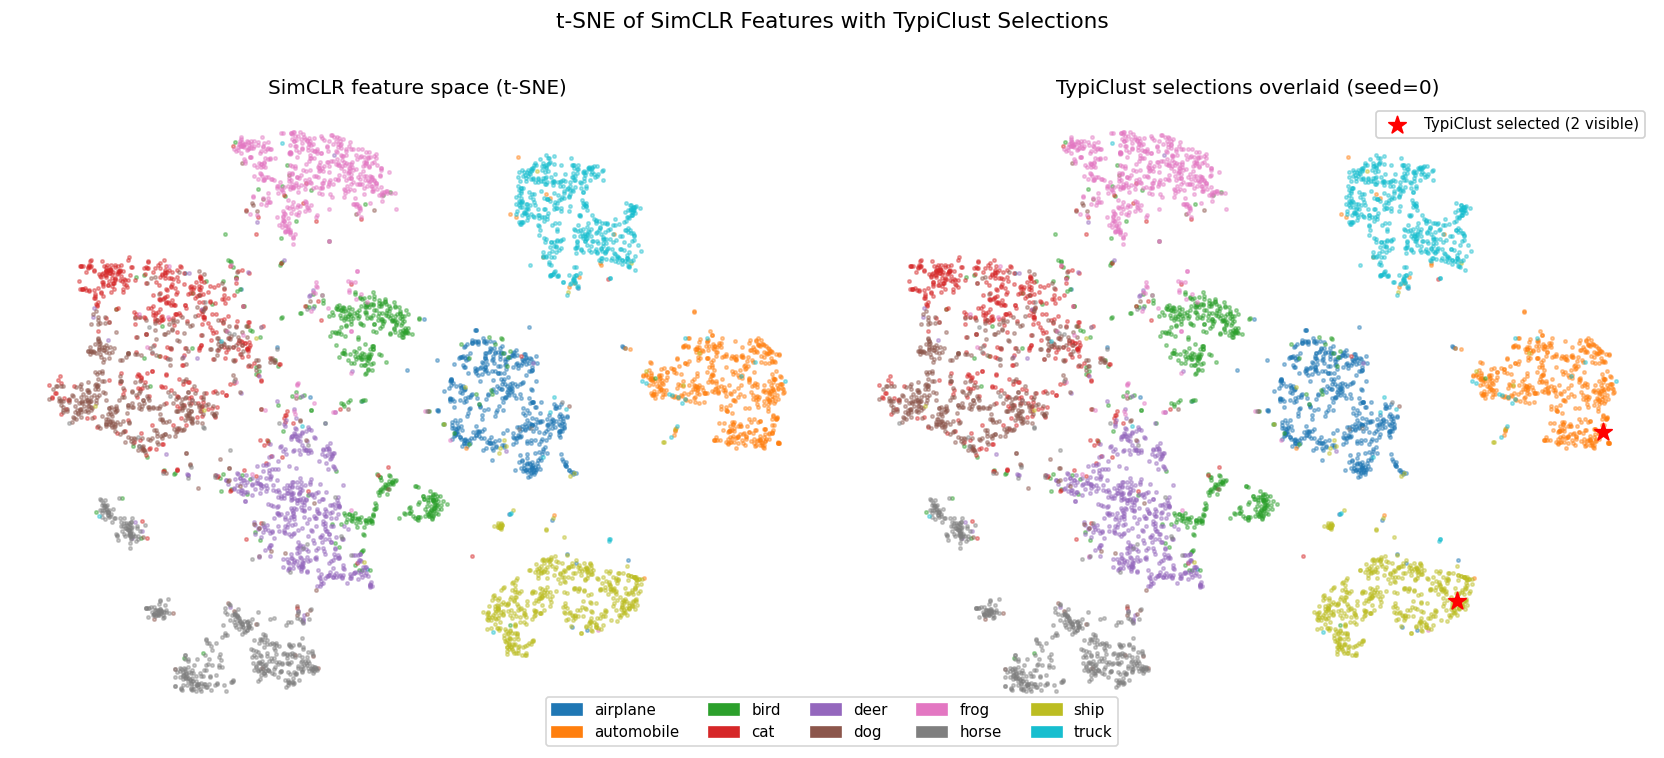

Saved -> plots/tsne_selected.pdf


In [31]:
# plot 3: t-SNE with TypiClust selections overlaid
tsne_emb = np.load(str(RESULTS_DIR / 'tsne_embeddings.npy'))
tsne_idx = np.load(str(RESULTS_DIR / 'tsne_indices.npy'))
tsne_set = set(tsne_idx.tolist())

# Gather all indices selected by TypiClust across all rounds (seed=0)
tc_selected_all = []
for rec in results_typiclust[0]:
    tc_selected_all.extend(rec['selected_indices'])
tc_selected_all = np.array(tc_selected_all)

# Which selected indices happen to be in the t-SNE subset?
tc_in_tsne = [i for i in tc_selected_all if i in tsne_set]
tsne_idx_list = tsne_idx.tolist()
tc_local_idx  = [tsne_idx_list.index(i) for i in tc_in_tsne]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax in axes:
    for c in range(NUM_CLASSES):
        mask = train_labels[tsne_idx] == c
        ax.scatter(tsne_emb[mask, 0], tsne_emb[mask, 1],
                   c=[CMAP(c)], s=4, alpha=0.4, rasterized=True)
    ax.axis('off')

# Left: plain feature space
axes[0].set_title('SimCLR feature space (t-SNE)', fontsize=12)

# Right: overlay selected points
if len(tc_local_idx) > 0:
    axes[1].scatter(
        tsne_emb[tc_local_idx, 0], tsne_emb[tc_local_idx, 1],
        c='red', s=120, marker='*', zorder=5,
        label='TypiClust selected ({} visible)'.format(len(tc_local_idx)),
    )
    axes[1].legend(loc='upper right', fontsize=9, framealpha=0.9)
axes[1].set_title('TypiClust selections overlaid (seed=0)', fontsize=12)

# Shared class legend at bottom
patches = [mpatches.Patch(color=CMAP(c), label=CIFAR10_CLASSES[c]) for c in range(NUM_CLASSES)]
fig.legend(handles=patches, loc='lower center', ncol=5,
           fontsize=9, bbox_to_anchor=(0.5, -0.02))

plt.suptitle('t-SNE of SimCLR Features with TypiClust Selections', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(str(PLOTS_DIR / 'tsne_selected.pdf'), bbox_inches='tight')
plt.show()
print('Saved -> plots/tsne_selected.pdf')

---
## Section 7: Statistical Analysis

At each budget level, test whether TypiClust accuracy significantly exceeds
Random using a **paired t-test** across seeds. Report Cohen's *d* effect size.

In [32]:
def cohens_d(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    diff = a - b
    sd = diff.std(ddof=1)
    if sd == 0:
        return 0.0
    return float(diff.mean() / sd)

def interpret_d(d):
    ad = abs(d)
    if ad < 0.2: return 'negligible'
    if ad < 0.5: return 'small'
    if ad < 0.8: return 'medium'
    return 'large'

In [33]:
print('Statistical analysis: TypiClust vs. Random  (paired t-test)\n')

if N_SEEDS < 2:
    print('WARNING: Only 1 seed -- statistical tests require N_SEEDS >= 2.')
    print('Re-run with N_SEEDS = 3 or more for valid p-values.')
    stat_rows = []
else:
    header = '{:>8s}  {:>9s}  {:>10s}  {:>8s}  {:>9s}  {:>7s}  {:>9s}  {:>10s}'.format(
        'Budget', 'TC mean', 'Rnd mean', 't-stat', 'p-value', 'Sig', "Cohen's d", 'Effect')
    print(header)
    print('-' * len(header))

    stat_rows = []
    for i, b in enumerate(agg_tc['budgets']):
        tc_accs  = agg_tc['matrix'][:, i]
        rnd_accs = agg_rnd['matrix'][:, i]

        t_stat, p_val = stats.ttest_rel(tc_accs, rnd_accs)
        d = cohens_d(tc_accs, rnd_accs)

        if p_val < 0.05:
            sig = '*'
        elif p_val < 0.10:
            sig = '~'
        else:
            sig = ''

        print('{:>8d}  {:>8.2f}%  {:>9.2f}%  {:>8.3f}  {:>9.4f}  {:>7s}  {:>9.3f}  {:>10s}'.format(
            b, tc_accs.mean(), rnd_accs.mean(), t_stat, p_val, sig, d, interpret_d(d)))

        stat_rows.append({
            'budget': b,
            't_stat': float(t_stat),
            'p_value': float(p_val),
            'cohens_d': float(d),
            'significant_005': bool(p_val < 0.05),
        })

    print('\n  * p < 0.05   ~ p < 0.10')
    save_results({'statistics': stat_rows}, str(RESULTS_DIR / 'statistical_analysis.json'))

Statistical analysis: TypiClust vs. Random  (paired t-test)

  Budget    TC mean    Rnd mean    t-stat    p-value      Sig  Cohen's d      Effect
------------------------------------------------------------------------------------
      10     16.54%      14.77%     0.967     0.4355               0.558      medium
      20     19.13%      17.44%     1.411     0.2938               0.814       large
      30     21.37%      19.82%     1.409     0.2942               0.813       large
      40     23.03%      21.04%     9.749     0.0104        *      5.629       large
      50     23.78%      22.16%     2.409     0.1376               1.391       large

  * p < 0.05   ~ p < 0.10
Results saved to ../results/statistical_analysis.json


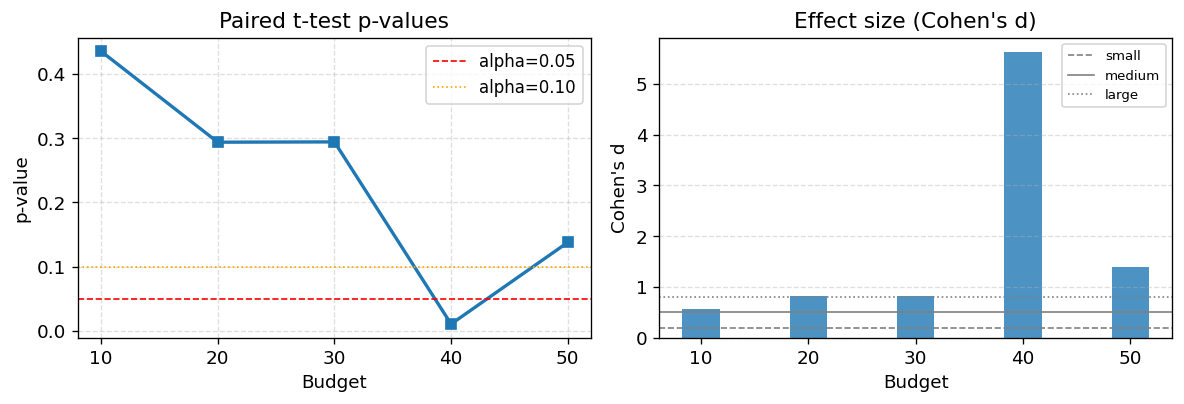

Saved -> plots/statistical_analysis.pdf


In [34]:
# p-value & effect-size plots
if N_SEEDS >= 2 and len(stat_rows) > 0:
    p_vals = [r['p_value'] for r in stat_rows]
    d_vals = [r['cohens_d'] for r in stat_rows]

    fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

    # p-values
    ax = axes[0]
    ax.plot(budgets_arr, p_vals, marker='s', color=TC_COLOR, linewidth=2)
    ax.axhline(0.05, color='red', linestyle='--', linewidth=1, label='alpha=0.05')
    ax.axhline(0.10, color='orange', linestyle=':', linewidth=1, label='alpha=0.10')
    ax.set_xlabel('Budget')
    ax.set_ylabel('p-value')
    ax.set_title('Paired t-test p-values')
    ax.set_xticks(budgets_arr)
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.4)

    # Cohen's d
    ax = axes[1]
    bar_colors = [TC_COLOR if d > 0 else RND_COLOR for d in d_vals]
    ax.bar(budgets_arr, d_vals, color=bar_colors, width=3.5, alpha=0.8)
    for thresh, lbl, ls in [(0.2, 'small', '--'), (0.5, 'medium', '-'), (0.8, 'large', ':')]:
        ax.axhline(thresh, color='gray', linestyle=ls, linewidth=1, label=lbl)
    ax.set_xlabel('Budget')
    ax.set_ylabel("Cohen's d")
    ax.set_title("Effect size (Cohen's d)")
    ax.set_xticks(budgets_arr)
    ax.legend(fontsize=8)
    ax.grid(True, axis='y', linestyle='--', alpha=0.4)

    plt.tight_layout()
    plt.savefig(str(PLOTS_DIR / 'statistical_analysis.pdf'), bbox_inches='tight')
    plt.show()
    print('Saved -> plots/statistical_analysis.pdf')
else:
    print('Skipping statistical plots (need N_SEEDS >= 2).')

---
## Section 8: Summary of Results

In [35]:
# paper-style summary table
W = 70
sep  = '-' * W
dsep = '=' * W

print(dsep)
print('{:^{}s}'.format('ACTIVE LEARNING ON CIFAR-10', W))
print('{:^{}s}'.format('TypiClust vs. Random  (Hacohen et al., ICML 2022)', W))
print(dsep)
print('Setup')
print('  Encoder      : ResNet-18 (SimCLR, {} epochs)'.format(SIMCLR_EPOCHS))
print('  Classifier   : ResNet-18 (from scratch, {} epochs/round)'.format(CLF_EPOCHS))
print('  Budget / rnd : {}   Rounds: {}   Seeds: {}'.format(BUDGET_B, N_ROUNDS, N_SEEDS))
print(sep)
print('{:>8s}  |  {:^22s}  |  {:^22s}  |  {:>5s}'.format(
    'Budget', 'TypiClust', 'Random', 'Delta'))
print('{:>8s}  |  {:^22s}  |  {:^22s}  |'.format(
    '', 'mean +/- std (%)', 'mean +/- std (%)'))
print(sep)

for i, b in enumerate(agg_tc['budgets']):
    tc_m  = agg_tc['mean'][i];   tc_s  = agg_tc['std'][i]
    rnd_m = agg_rnd['mean'][i];  rnd_s = agg_rnd['std'][i]
    delta = tc_m - rnd_m
    tc_str  = '{:.2f} +/- {:.2f}'.format(tc_m, tc_s)
    rnd_str = '{:.2f} +/- {:.2f}'.format(rnd_m, rnd_s)
    print('{:>8d}  |  {:^22s}  |  {:^22s}  |  {:>+5.2f}%'.format(
        b, tc_str, rnd_str, delta))

print(dsep)

best_tc  = agg_tc['mean'][-1]
best_rnd = agg_rnd['mean'][-1]
print('Final budget ({} labels):'.format(BUDGETS[-1]))
print('  TypiClust : {:.2f}% +/- {:.2f}%'.format(best_tc, agg_tc['std'][-1]))
print('  Random    : {:.2f}% +/- {:.2f}%'.format(best_rnd, agg_rnd['std'][-1]))
print('  Gain      : {:+.2f}%'.format(best_tc - best_rnd))
print(dsep)

                     ACTIVE LEARNING ON CIFAR-10                      
          TypiClust vs. Random  (Hacohen et al., ICML 2022)           
Setup
  Encoder      : ResNet-18 (SimCLR, 460 epochs)
  Classifier   : ResNet-18 (from scratch, 200 epochs/round)
  Budget / rnd : 10   Rounds: 5   Seeds: 3
----------------------------------------------------------------------
  Budget  |        TypiClust         |          Random          |  Delta
          |     mean +/- std (%)     |     mean +/- std (%)     |
----------------------------------------------------------------------
      10  |      16.54 +/- 0.92      |      14.77 +/- 2.90      |  +1.76%
      20  |      19.13 +/- 0.46      |      17.44 +/- 2.04      |  +1.68%
      30  |      21.37 +/- 0.31      |      19.82 +/- 1.66      |  +1.56%
      40  |      23.03 +/- 0.77      |      21.04 +/- 0.53      |  +2.00%
      50  |      23.78 +/- 0.34      |      22.16 +/- 1.44      |  +1.62%
Final budget (50 labels):
  TypiClust : 23.78% +/-

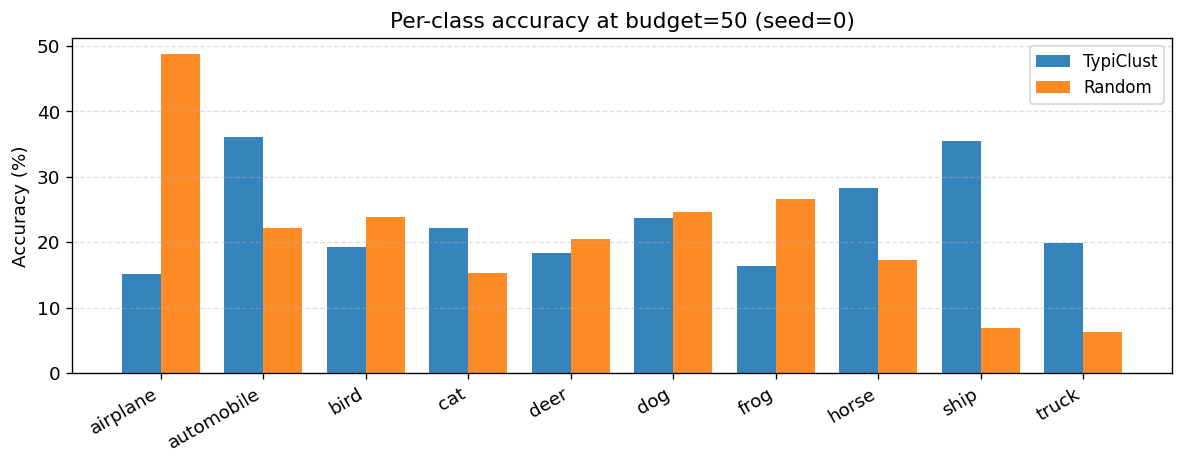

Saved -> plots/per_class_accuracy.pdf


In [36]:
# per-class accuracy at final budget (seed=0)
tc_per_class  = np.array(results_typiclust[0][-1]['per_class_acc'])
rnd_per_class = np.array(results_random[0][-1]['per_class_acc'])

fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(NUM_CLASSES)
w = 0.38
ax.bar(x - w/2, tc_per_class,  width=w, color=TC_COLOR,  label='TypiClust', alpha=0.9)
ax.bar(x + w/2, rnd_per_class, width=w, color=RND_COLOR, label='Random',    alpha=0.9)
ax.set_xticks(x)
ax.set_xticklabels(CIFAR10_CLASSES, rotation=30, ha='right')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Per-class accuracy at budget={} (seed=0)'.format(BUDGETS[-1]))
ax.legend()
ax.grid(True, axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig(str(PLOTS_DIR / 'per_class_accuracy.pdf'), bbox_inches='tight')
plt.show()
print('Saved -> plots/per_class_accuracy.pdf')

In [37]:
# list all saved outputs
print('Results files:')
for pattern in ['../results/*.json', '../results/*.npy', '../results/*.pt']:
    for f in sorted(glob.glob(pattern)):
        size_kb = Path(f).stat().st_size / 1024
        print('  {}  ({:.1f} KB)'.format(f, size_kb))

print('\nPlot files:')
for pattern in ['../plots/*.pdf', '../plots/*.png']:
    for f in sorted(glob.glob(pattern)):
        size_kb = Path(f).stat().st_size / 1024
        print('  {}  ({:.1f} KB)'.format(f, size_kb))

Results files:
  ../results/combined_with_paper.json  (1.5 KB)
  ../results/fw2_random_results.json  (7.9 KB)
  ../results/fw2_typiclust_results.json  (8.1 KB)
  ../results/random_results.json  (8.1 KB)
  ../results/statistical_analysis.json  (0.9 KB)
  ../results/typiclust_results.json  (8.2 KB)
  ../results/test_features.npy  (20000.1 KB)
  ../results/test_labels.npy  (78.2 KB)
  ../results/train_features.npy  (100000.1 KB)
  ../results/train_labels.npy  (390.8 KB)
  ../results/tsne_embeddings.npy  (39.2 KB)
  ../results/tsne_indices.npy  (39.2 KB)

Plot files:
  ../plots/accuracy_vs_budget.pdf  (16.4 KB)
  ../plots/accuracy_vs_budget_with_paper.pdf  (20.1 KB)
  ../plots/cifar10_samples.pdf  (64.4 KB)
  ../plots/final_accuracy_bar.pdf  (14.4 KB)
  ../plots/fw2_accuracy_vs_budget.pdf  (17.8 KB)
  ../plots/per_class_accuracy.pdf  (15.4 KB)
  ../plots/statistical_analysis.pdf  (15.0 KB)
  ../plots/tsne_selected.pdf  (215.8 KB)
  ../plots/tsne_simclr_features.pdf  (199.0 KB)


In [39]:
import os
import shutil

# This will zip the folders sitting in /kaggle/working/
# which is where your .npy files and plots actually live.
output_filename = "/kaggle/working/FINAL_COURSEWORK_DATA"

# We will create a temporary folder to gather everything
temp_dir = "/kaggle/working/export_temp"
os.makedirs(temp_dir, exist_ok=True)

# Copy the actual results and plots folders
for folder in ['results', 'plots']:
    src = f"/kaggle/working/{folder}"
    if os.path.exists(src):
        shutil.copytree(src, os.path.join(temp_dir, folder), dirs_exist_ok=True)

# Zip the gathered data
shutil.make_archive(output_filename, 'zip', temp_dir)

# Clean up
shutil.rmtree(temp_dir)
print(f"Success! Download this file now: {output_filename}.zip")

Success! Download this file now: /kaggle/working/FINAL_COURSEWORK_DATA.zip
